In [1]:
from fredapi import Fred
import yfinance as yf
import pandas_datareader.data as web

import importlib
import seaborn as sns
import backtester
importlib.reload(backtester)

from backtester import Backtester
from backtester import Strategy

# from backtester import DataHandler
# import Ruff
# import Black
# import MyPy

# Backtesting

* example strategy: buy Gold when 20 day moving average > 60 day moving average
* backtest: check Gold's prices in the past and trade under condition
* results: show if the trades were profitable

In [2]:

mineral_stocks = [
    'GC=F',  # Gold
    # 'HG=F',  # Copper
    # 'PA=F',  # Palladium
    # 'PL=F',  # Platinum
    # 'SI=F',  # Silver
]
start_date = "2020-01-01"
end_date = "2024-12-31"

data = yf.download(mineral_stocks,start=start_date,end=end_date,auto_adjust=True)['Close']


[*********************100%***********************]  1 of 1 completed


In [3]:
close_name = ['close' for x in data.columns]
data.columns = close_name

Final Portfolio Value: 10223.72
Total Return: 2.24%
Annualized Return: 0.44%
Annualized Volatility: 1.21%
Sharpe Ratio: -1.28
Sortino Ratio: -1.20
Maximum Drawdown: -1.76%


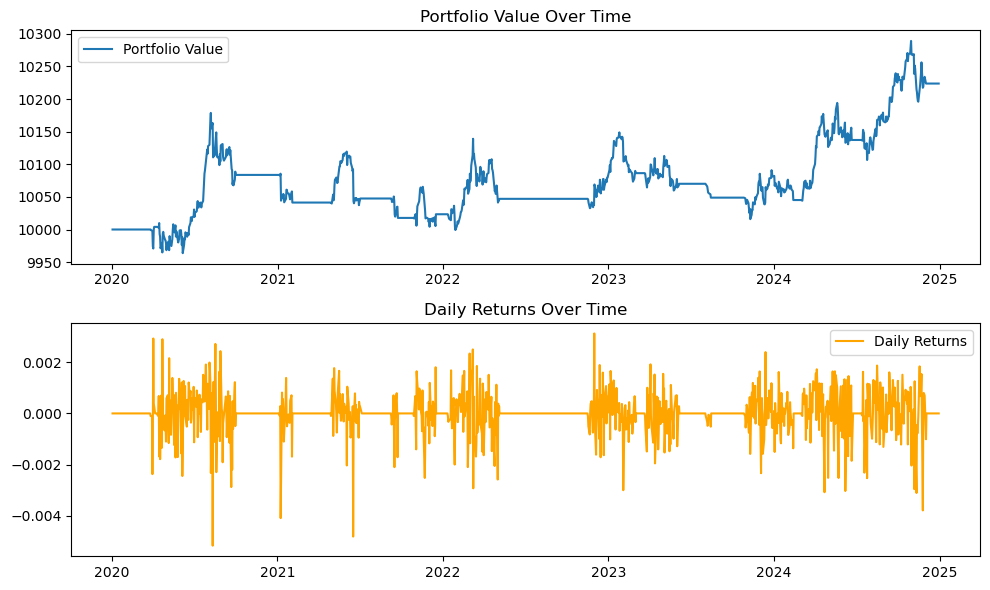

In [5]:
# Define your strategy, indicators, and signal logic here
strategy = Strategy(
    indicators={
        "sma_20": lambda df: df["close"].rolling(window=20).mean(),
        "sma_60": lambda df: df["close"].rolling(window=60).mean(),
    },
    signal_logic=lambda row: 1 if row["sma_20"] > row["sma_60"] else -1,
)

data = strategy.generate_signals(data)
backtester = Backtester()
backtester.backtest(data)
backtester.calculate_performance()

In [6]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf, pacf, acf

In [278]:
backtester.assets_data

{'SINGLE_ASSET': {'cash': 0.0,
  'positions': 28.752487010762565,
  'position_value': 13999.01101619308,
  'total_value': 13999.01101619308}}

[*********************100%***********************]  1 of 1 completed


Final Portfolio Value: 10190.21
Total Return: 1.90%
Annualized Return: 1.91%
Annualized Volatility: 1.39%
Sharpe Ratio: -0.06
Sortino Ratio: -0.07
Maximum Drawdown: -0.73%


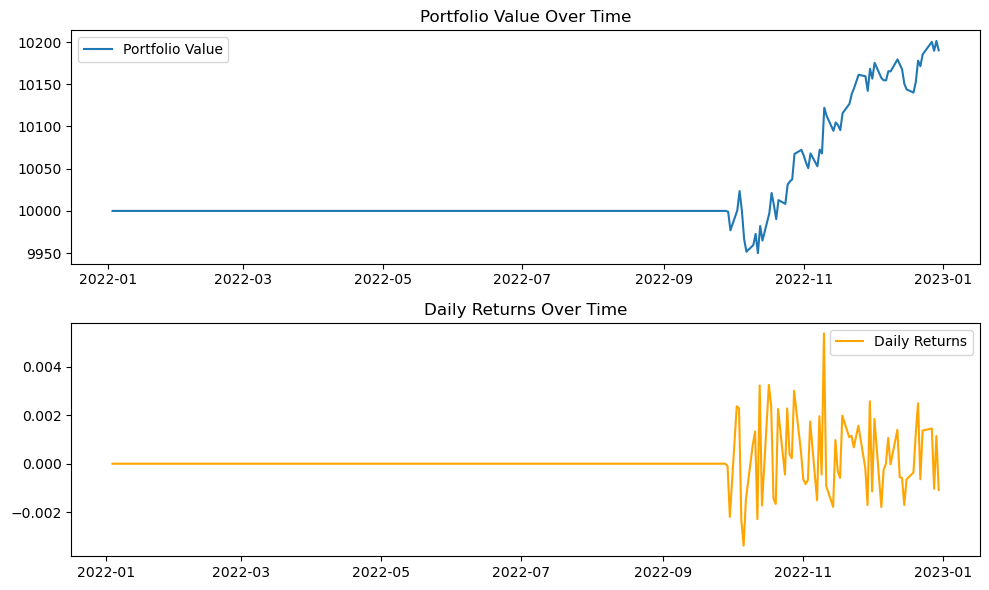

In [6]:
symbol = "HE"
start_date = "2022-01-01"
end_date = "2022-12-31"

data = yf.download(symbol,start=start_date,end=end_date,auto_adjust=True)['Close']
close_name = ['close' for x in data.columns]
data.columns = close_name

# Define your strategy, indicators, and signal logic here


strategy = Strategy(
    indicators={
        "sma_50": lambda df: df["close"].rolling(window=50).mean(),
        "std_3": lambda df: df["sma_50"].std() * 3,
        "std_3_upper": lambda df: df["sma_50"] + df["std_3"],
        "std_3_lower": lambda df: df["sma_50"] - df["std_3"],
    },
    signal_logic=lambda df: (
        1
        if df["close"] < df["std_3_lower"]
        else -1 if df["close"] > df["std_3_upper"] else 0
    ),
)


data = strategy.generate_signals(data)

backtester = Backtester()
backtester.backtest(data)
backtester.calculate_performance()

[*********************100%***********************]  2 of 2 completed


Final Portfolio Value: 11080.34
Total Return: 10.80%
Annualized Return: 8.61%
Annualized Volatility: 4.76%
Sharpe Ratio: 1.39
Sortino Ratio: 2.46
Maximum Drawdown: -4.19%


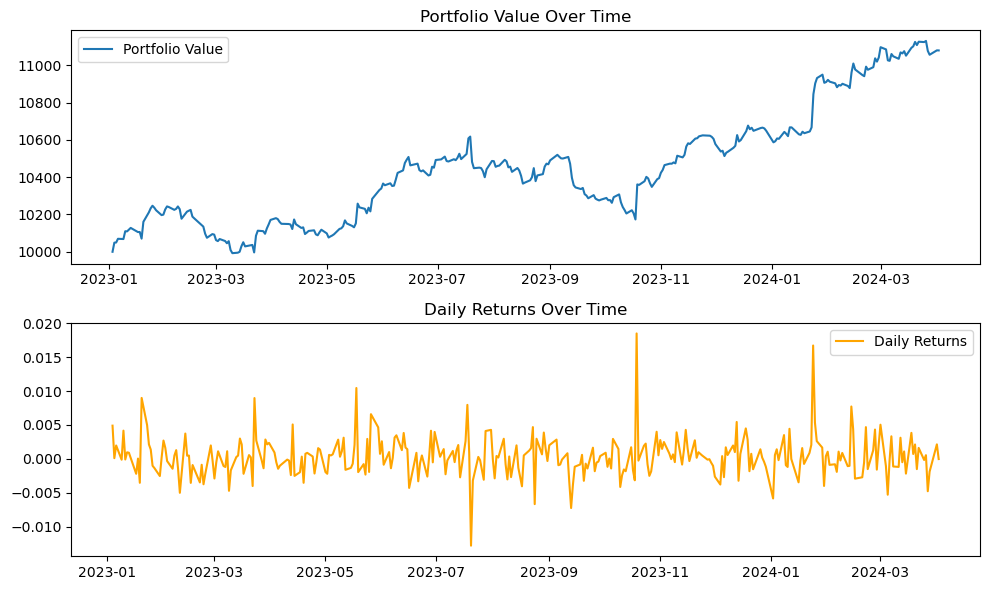

In [7]:
tickers = ["NFLX","ROKU"]
start_date = "2023-01-01"
end_date = "2024-04-03"

data = yf.download(tickers,start=start_date,end=end_date,auto_adjust=True)['Close']


data = data.rename(columns={"NFLX":'close_NFLX','ROKU':'close'})


strategy = Strategy(
    indicators={
        "NFLX_volatility": lambda df: df["close_NFLX"].pct_change().std(),
        "ROKU_volatility": lambda df: df["close"].pct_change().std(),
    },
    signal_logic=lambda row: (
        1
        if (row["NFLX_volatility"] / row["ROKU_volatility"] < .55)
        else -1 if (row["NFLX_volatility"] / row["ROKU_volatility"] > 1.85 ) 
        else 0

    ),
)

#
data = strategy.generate_signals(data)

backtester = Backtester()
backtester.backtest(data)
backtester.calculate_performance()